# Notebook 13 | Central Limit Theorem

In [1]:
from foundations_of_probability_and_statistics.cars.horsepower_moments import conditional_horsepower_mean
from foundations_of_probability_and_statistics.cars.horsepower_moments import conditional_horsepower_variance
from foundations_of_probability_and_statistics.cars.sample_from_car_distribution import sample_from_car_distribution

import pandas as pd

# show all rows of data frames and series per default
pd.set_option("display.max_rows", None)

## The central limit theorem: means become normal, data do not

What is the sampling distribution of an estimator once the sample is large? The central limit theorem (CLT) answers: approximately normal. Fix a brand $b$, let $X = (H \mid B = b)$ be one draw with mean $\mu_b = \mathbb{E}[H \mid B = b]$ and variance $\sigma_b^2 = \mathrm{Var}(H \mid B = b)$ (notebooks 10-11), and let $\bar{X}_n^{(b)}$ be the estimator, known as the sample mean, of $\mu_b$ from $n$ independent draws $X_1, \dots, X_n$. An estimator is characterized by two quantities: the bias of the estimator, $\mathbb{E}[\bar{X}_n^{(b)}] - \mu_b = 0$ (the sample mean is without bias), and the variance of the estimator, $\mathrm{Var}(\bar{X}_n^{(b)}) = \sigma_b^2 / n$. The CLT adds the shape of its sampling distribution, namely approximately normal for large $n$ whatever the shape of $X$:

$$\bar{X}_n^{(b)} \overset{\cdot}{\sim} \mathcal{N}\left(\mu_b, \, \frac{\sigma_b^2}{n}\right), \qquad Z = \frac{\bar{X}_n^{(b)} - \mu_b}{\sigma_b / \sqrt{n}} \overset{\cdot}{\sim} \mathcal{N}(0, 1).$$

The standardized $Z$ is the object of study: subtract the center, divide by the shrinking scale $\sigma_b / \sqrt{n}$, and every brand's estimator lands on the same standard normal curve.

## Derivation

1. Fix $X = (H \mid B = \text{VW})$ with $\mu = 150$ and $\sigma = \sqrt{4500} \approx 67.08$.
2. Standardize the estimator: the sample-mean estimator $\bar{X}_n^{(b)}$ has bias zero and variance of the estimator $\sigma^2 / n$, so $Z = (\bar{X}_n^{(b)} - \mu) / (\sigma / \sqrt{n})$ -- center, then scale to unit variance.
3. The CLT states that the standardized estimator $Z$ is approximately standard normal for large $n$ whenever the draws are independent and identically distributed with finite variance; the shape of $X$ itself is irrelevant.
4. With $n = 50$ and $\bar{x} = 160$ this gives $z \approx 1.05$: a one-sigma event, unremarkable under the normal curve.

Why $n = 50$ suffices: averaging 50 bounded draws already smooths the three-point VW distribution into a bell shape; heavier tails would demand more. The characteristic mistake is reading the CLT as a claim about raw data: the VW table stays three-valued however large $n$ grows, and only the estimator's sampling distribution turns normal.

## Worked example (by hand)

One worked z-score for $X = (H \mid B = \text{VW})$ with $\mu = 150$, $\sigma = \sqrt{4500} \approx 67.08$, $n = 50$ and $\bar{x} = 160$:

$$z = \frac{160 - 150}{67.08 / \sqrt{50}} \approx 1.05.$$

The denominator $\sigma / \sqrt{n} \approx 9.49$ is the standard error of the estimator $\bar{X}_n^{(b)}$, the square root of its variance $\sigma^2 / n$: the typical wiggle room of a 50-car average. A deviation of 10 hp is therefore barely one wiggle -- $z \approx 1$ never surprises.

In [2]:
import math

# one worked z-score for X = (H | B = VW): mu = 150, sigma = sqrt(4500), n = 50, xbar = 160
mu = conditional_horsepower_mean("VW")
sigma = math.sqrt(conditional_horsepower_variance("VW"))
se = sigma / math.sqrt(50)
z = (160 - mu) / se
assert math.isclose(mu, 150.0)
assert math.isclose(sigma, 67.08, rel_tol=1e-4)
assert math.isclose(se, 9.49, rel_tol=1e-2)
assert math.isclose(z, 1.05, rel_tol=0.01)
z

1.05409255338946

## Generalization

One sample of 500,000 cars: every set of $n = 50$ consecutive draws yields one realization of the sample-mean estimator $\bar{X}_n^{(b)}$, histogrammed against the exact normal $\mathcal{N}(\mu_b, \sigma_b^2 / n)$ built from notebook 11's moments. The bins match the 2 hp lattice of achievable estimator values, so each bar spreads exactly one lattice cell and no discrete mass piles up above the curve. Notebook 12 showed the estimator converging to $\mu_b$; this notebook describes the sampling distribution of its remaining fluctuations: bias zero, variance of the estimator $\sigma_b^2 / n$. The standardized asserts below check what the eye sees: mean near 0, variance near 1 for every brand. Three discrete, skewed, mutually different conditional tables -- one universal limit shape. Notebook 14 turns to the practical question: what does one sample say, and how do we show it honestly?

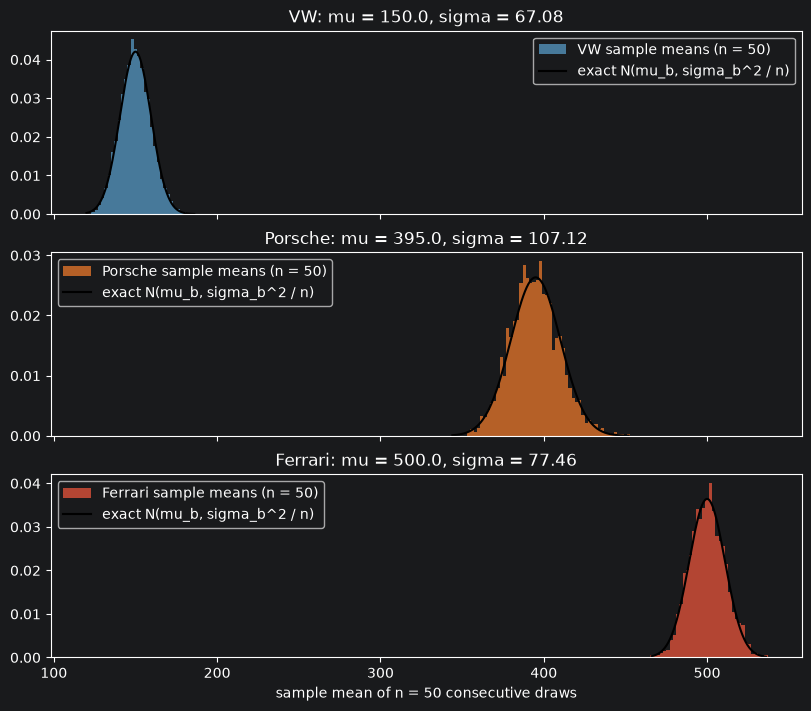

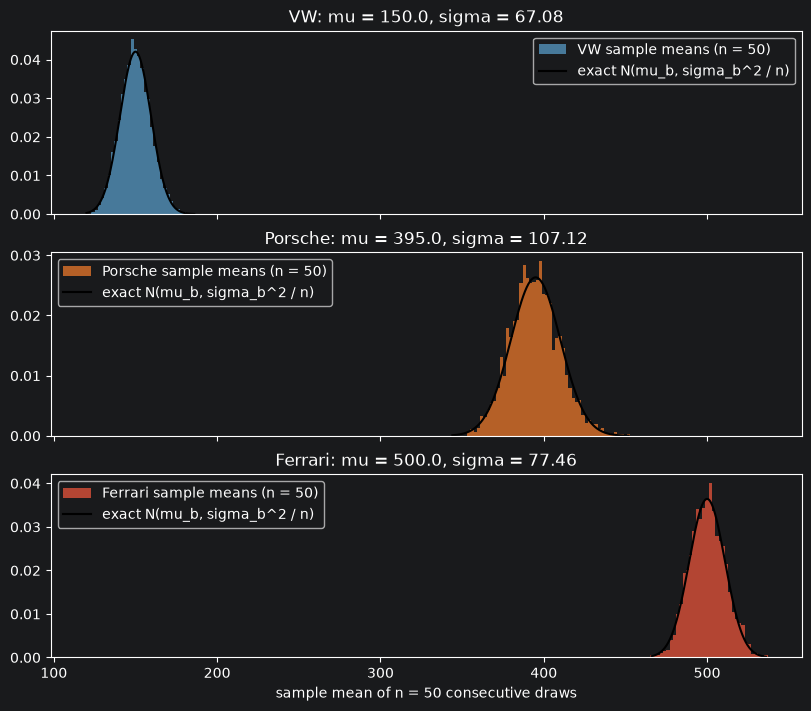

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

cars = sample_from_car_distribution(n_cars=500_000, random_state=42)

# realizations of the sample-mean estimator from n = 50 consecutive draws against N(mu_b, sigma_b^2 / n)
n = 50
figure, axes = plt.subplots(3, 1, figsize=(8.0, 7.0), dpi=100, layout="constrained", sharex=True)
for ax, brand, cmap_name in zip(axes, ["VW", "Porsche", "Ferrari"], ["Blues", "Oranges", "Reds"], strict=True):
    values = cars[cars["brand"] == brand]["horsepower"].to_numpy(dtype=float)
    sample_means = values[: len(values) // n * n].reshape(-1, n).mean(axis=1)
    mu = conditional_horsepower_mean(brand)
    sigma = float(np.sqrt(conditional_horsepower_variance(brand)))
    # the unbiased estimator's standardized values have mean ~0 and variance ~1 under the CLT
    standardized = (sample_means - mu) / (sigma / np.sqrt(n))
    assert abs(float(standardized.mean())) < 0.05
    assert math.isclose(float(standardized.var(ddof=0)), 1.0, rel_tol=0.05)
    grid = np.linspace(sample_means.min(), sample_means.max(), 200)
    # the estimator values sit on a lattice: n consecutive draws shift the total by
    # multiples of 100 hp, so the values are spaced 100 / n = 2 hp apart; bins narrower
    # than one lattice cell pile discrete mass into single bars and overshoot any
    # continuous density, so center one edge pair on every lattice value instead
    unique = np.unique(np.round(sample_means, 12))
    spacing = float(np.min(np.diff(unique)))
    edges = np.concatenate([unique - spacing / 2, [unique[-1] + spacing / 2]])
    ax.hist(sample_means, bins=edges, density=True, color=matplotlib.colormaps[cmap_name](0.55), alpha=0.7, label=f"{brand} sample means (n = 50)")
    ax.plot(grid, stats.norm.pdf(grid, loc=mu, scale=sigma / np.sqrt(n)), color="black", label="exact N(mu_b, sigma_b^2 / n)")
    ax.set_title(f"{brand}: mu = {mu:.1f}, sigma = {sigma:.2f}")
    ax.legend()
axes[-1].set_xlabel("sample mean of n = 50 consecutive draws")
figure

## References

- Blitzstein, J. K., Hwang, J. (2019): "Introduction to Probability", 2nd ed., Chapman & Hall/CRC, chapter "Inequalities and Limit Theorems" (CLT is a named section), https://www.routledge.com/Introduction-to-Probability-Second-Edition/Blitzstein-Hwang/p/book/9781138369917 (free PDF: https://probabilitybook.net/).
- Wasserman, L. (2004): "All of Statistics: A Concise Course in Statistical Inference", Springer Texts in Statistics, chapter "Convergence of Random Variables" (LLN, CLT), https://doi.org/10.1007/978-0-387-21736-9.
- scipy.stats.rv_discrete, https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_discrete.html.